<a href="https://colab.research.google.com/github/AndresMontesDeOca/NLP_1/blob/main/Desafios/Desafio_3_AndresMontesDeOca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

# Desafio #3

## Objetivo Principal
Crear y entrenar un modelo de lenguaje basado en redes neuronales recurrentes que utilice tokenización por caracteres en lugar de por palabras, para luego generar nuevas secuencias de texto.

In [4]:
# # Librerias
# !pip install -q gdown PyPDF2

import pandas as pd
import numpy as np
import gdown
import PyPDF2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split



pd.set_option('display.max_colwidth', None)

## 1. Selección y Preprocesamiento del Corpus
*   **Selección de datos:** Elegir un corpus de texto (se recomienda reutilizar el conjunto de datos de trabajos previos). Si se presentan problemas de velocidad o memoria por el tamaño del corpus, se permite reducir la cantidad de capítulos o texto utilizado.
*   **Preparación y Tokenización:** Realizar el preprocesamiento necesario para tokenizar el texto a nivel de caracteres y estructurar el dataset.
*   **Ventana de contexto:** Definir y justificar el tamaño de la ventana de contexto analizando la distribución de los datos mediante **histogramas**. Aplicar truncado y *padding* según corresponda.
*   **Split:** Separar el dataset estructurado en conjuntos de entrenamiento (*train*) y validación (*validation*).

### 1.1 Data Load

In [6]:
# Descargar el archivo desde Google Drive usando su ID
file_id = '0Bzr5RihQVFTfWndxTG43cVVPcnM'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'comunidad_del_anillo.pdf'
gdown.download(url, output, quiet=False)

# Extraer el texto del PDF
text = ""
with open(output, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + " "

# Reemplazar los saltos de línea (renglones del PDF) por espacios
text = text.replace('\n', ' ')

# Dividir el texto en oraciones utilizando el punto
lineas = text.split('.')

df_lotr = pd.DataFrame(lineas, columns=['oracion'])
# Filtrar líneas vacías
df_lotr = df_lotr[df_lotr['oracion'].str.strip() != '']

print(f"Cantidad de oraciones extraídas: {df_lotr.shape[0]}")
df_lotr.head(5)

Downloading...
From: https://drive.google.com/uc?id=0Bzr5RihQVFTfWndxTG43cVVPcnM
To: /content/comunidad_del_anillo.pdf
100%|██████████| 1.32M/1.32M [00:00<00:00, 140MB/s]


Cantidad de oraciones extraídas: 11107


,oracion
0,"El Señor de los Anillos JRR Tolkien PARTE I: La Comunidad del Anillo PROLOGO 1 De los Hobbits Este libro trata principalmente de los Hobbits, y el lector descubrirá en sus páginas mucho del carácter y algo de la historia de este pueblo"
1,Podrá encontrarse más información en los extractos del Libro Rojo de la Frontera de l Oeste que ya han sido publicados con el título de El Hobbit
2,"El relato tuvo su origen en los primeros capítulos del Libro Rojo, compuesto por Bilbo Bolsón -el primer Hobbit que fue famoso en el mundo entero - y que él tituló Historia de una ida y de una vuelta, pues contaba el viaje de Bilbo hacia el Este y la vuelta, aventura que más tarde enredaría a todos los Hobbits en los importantes acontecimientos que aquí se relatan"
3,"No obstante, muchos querrán saber desde un principio algo más de este pueblo notable y quizás algunos no tengan el libro anterior"
4,"Para esos lectores se han reunido aquí algunas notas sobre los puntos más importantes de la tradición hobbit, y se recuerda brevemente la primera aventura"


### 1.2 Preparación y Tokenización

In [7]:
# Obtener el vocabulario (caracteres únicos en el texto)
vocab = sorted(set(text))
print(f'Número de caracteres únicos (tamaño del vocabulario): {len(vocab)}')

# Crear diccionarios para mapear caracteres a índices y viceversa
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

# Convertir el texto completo a una secuencia de enteros
text_as_int = np.array([char2idx[c] for c in text])

print("\nTexto original (primeros 50 caracteres):")
print(repr(text[:50]))
print("\nTexto tokenizado (primeros 50 enteros):")
print(text_as_int[:50])


Número de caracteres únicos (tamaño del vocabulario): 95

Texto original (primeros 50 caracteres):
'El Señor de los Anillos   JRR Tolkien     PARTE I:'

Texto tokenizado (primeros 50 enteros):
[26 60  0 40 53 89 63 66  0 52 53  0 60 63 67  0 22 62 57 60 60 63 67  0
  0  0 31 39 39  0 41 63 60 59 57 53 62  0  0  0  0  0 37 22 39 41 26  0
 30 19]


### 1.3 Ventana de Contexto

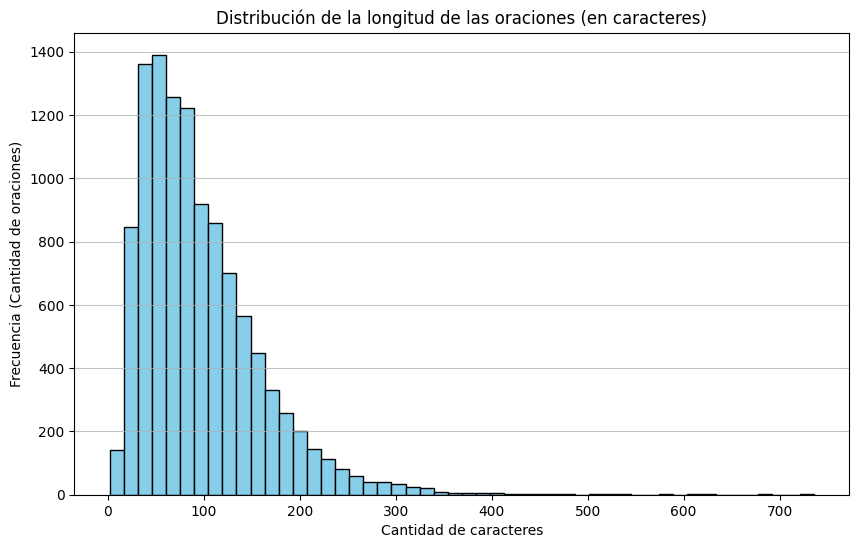

Estadísticas de la longitud de oraciones (en caracteres):
count    11107.000000
mean        95.813901
std         61.647345
min          2.000000
25%         51.000000
50%         82.000000
75%        126.000000
max        736.000000
dtype: float64


In [8]:
# Calcular la longitud de cada oración en caracteres
length_sentences_chars = [len(oracion) for oracion in df_lotr['oracion']]

# Graficar el histograma
plt.figure(figsize=(10, 6))
plt.hist(length_sentences_chars, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la longitud de las oraciones (en caracteres)')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia (Cantidad de oraciones)')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Mostrar algunas estadísticas descriptivas
print("Estadísticas de la longitud de oraciones (en caracteres):")
print(pd.Series(length_sentences_chars).describe())

In [9]:
# Percentil 90
max_context_size = int(np.percentile(length_sentences_chars, 90) - 1)

print(f'max_context_size: {max_context_size}')

max_context_size: 174


In [12]:
# Convertir cada oración en una lista de enteros
sentences_as_int = [
    [char2idx[c] for c in oracion if c in char2idx]
    for oracion in df_lotr['oracion']
]

# Aplicar padding y truncado (max_context_size + 1 para incluir el target)
pad_value = char2idx.get(' ', 0)
padded_sequences = pad_sequences(
    sentences_as_int,
    maxlen=max_context_size + 1,
    padding='pre',
    truncating='pre',
    value=pad_value
)

### 1.4 Split

In [13]:


# Separar en X (entradas) e y (targets)
X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
print(f"Dimensiones de X (entradas): {X.shape}")
print(f"Dimensiones de y (targets): {y.shape}")

# Split en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_val: {X_val.shape}")

Dimensiones de X (entradas): (11107, 174)
Dimensiones de y (targets): (11107,)

Tamaño de X_train: (8885, 174)
Tamaño de X_val: (2222, 174)


## 2. Arquitectura y Entrenamiento
*   **Modelos:** Proponer arquitecturas de redes neuronales recurrentes. Se sugiere explorar *SimpleRNN* (celda de Elman) como línea base, para luego enfocarse en arquitecturas más robustas como **LSTM** o **GRU**.
*   **Optimizador:** Se recomienda el uso de `rmsprop` para lograr una buena convergencia, aunque es válido experimentar con otros.
*   **Métrica y Early Stopping:** El entrenamiento debe guiarse por el descenso de la **perplejidad** en los datos de validación (utilizar el *callback* provisto para finalizar el entrenamiento en el momento óptimo).
*   **Hardware:** Se requiere utilizar una GPU para mejorar los tiempos de procesamiento.

## 3. Generación de Secuencias (Búsqueda)
Con el o los mejores modelos entrenados, generar nuevas secuencias a partir de secuencias de contexto (semillas) implementando y comparando las siguientes estrategias:
*   **Greedy Search.**
*   **Beam Search determinístico.**
*   **Beam Search estocástico.** Para esta estrategia, se debe analizar explícitamente el efecto de la **temperatura** en la generación de secuencias y cómo ajustarla ayuda a mitigar los bucles de repetición.

## 4. Documentación y Análisis de Resultados
*   Registrar en la notebook los experimentos realizados: variaciones de arquitectura, tamaños de *embeddings* y ajustes de hiperparámetros.
*   Monitorear la perplejidad a lo largo de los experimentos.
*   Presentar conclusiones sobre la comparación entre las distintas arquitecturas probadas y las estrategias de generación de texto.